# 01 — Load, Verify, and Visualize EEG

This notebook loads the first real PhysioNet EEG Motor Movement/Imagery EDF file, inspects the MNE `Raw` object, checks metadata and annotations, converts annotations into events, and creates basic visualizations.

### Imports

In [1]:


from pathlib import Path

import mne
from mne.datasets import eegbci
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

mne.set_log_level("WARNING")

### Objective

The goal of this notebook is not to train a model yet. The goal is to verify that I can load one real EEG recording, inspect its structure, understand its annotations, and create basic visualizations.

### Project paths

In [2]:


PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data" / "raw" / "eegbci"
FIGURES_DIR = PROJECT_ROOT / "figures"
RESULTS_DIR = PROJECT_ROOT / "results"

DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)
print("Figures directory:", FIGURES_DIR)
print("Results directory:", RESULTS_DIR)

Project root: /Users/heihei/Desktop/neurosignallab
Data directory: /Users/heihei/Desktop/neurosignallab/data/raw/eegbci
Figures directory: /Users/heihei/Desktop/neurosignallab/figures
Results directory: /Users/heihei/Desktop/neurosignallab/results


### Download Subject 1 Run 4

In [3]:
subject = 1
runs = [4]

raw_fnames = eegbci.load_data(subjects=subject, runs=runs, path=DATA_DIR)
raw_fnames

[PosixPath('/Users/heihei/Desktop/neurosignallab/data/raw/eegbci/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R04.edf')]

### Load Raw object

In [4]:
raw_path = raw_fnames[0]

raw = mne.io.read_raw_edf(raw_path, preload=True)

raw

<RawEDF | S001R04.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>

The EDF file loaded successfully as an MNE `RawEDF` object.

This recording contains 64 EEG channels, sampled at 160 Hz, with 20,000 time points. The duration is approximately 125 seconds, since:

20,000 samples / 160 samples per second = 125 seconds

At this stage, the data is still continuous raw EEG. It has not yet been converted into epochs or prepared for machine learning.

### Metadata dictionary

In [5]:
metadata = {
    "n_channels": int(len(raw.ch_names)),
    "sampling_frequency_hz": float(raw.info["sfreq"]),
    "n_samples": int(raw.n_times),
    "duration_seconds": float(raw.times[-1]),
}

metadata

{'n_channels': 64,
 'sampling_frequency_hz': 160.0,
 'n_samples': 20000,
 'duration_seconds': 124.99375}

### Channel names and raw shape

In [6]:
print(raw.ch_names[:20])
raw.get_data().shape

['Fc5.', 'Fc3.', 'Fc1.', 'Fcz.', 'Fc2.', 'Fc4.', 'Fc6.', 'C5..', 'C3..', 'C1..', 'Cz..', 'C2..', 'C4..', 'C6..', 'Cp5.', 'Cp3.', 'Cp1.', 'Cpz.', 'Cp2.', 'Cp4.']


(64, 20000)

The raw EEG data has shape `(64, 20000)`, meaning 64 EEG channels and 20,000 time samples.

This matches the metadata: the recording was sampled at 160 Hz for approximately 125 seconds.

At this stage, the data is still continuous raw EEG. It has not yet been segmented into epochs, so the shape is `channels × time`, not `epochs × channels × time`.

The channel names show the electrode labels loaded from the EDF file. Some names include dots because of how the channel labels are stored in the dataset. These can be standardized later if needed.

## Inspect annotations

### Annotation object

In [7]:
raw.annotations

<Annotations | 30 segments: T0 (15), T1 (8), T2 (7)>

### Annotations Dataframe

In [8]:
annotations_df = pd.DataFrame({
    "onset": raw.annotations.onset,
    "duration": raw.annotations.duration,
    "description": raw.annotations.description,
})

annotations_df

,onset,duration,description
0,0.0,4.2,T0
1,4.2,4.1,T2
2,8.3,4.2,T0
3,12.5,4.1,T1
4,16.6,4.2,T0
5,20.8,4.1,T1
6,24.9,4.2,T0
7,29.1,4.1,T2
8,33.2,4.2,T0
9,37.4,4.1,T2


## Convert annotations to events

The EDF file stores task labels as annotations. MNE can convert these annotations into an events array and an `event_id` dictionary.

The events array will later be used to create epochs.

### Check extracted event_id and event array

In [9]:
events, event_id = mne.events_from_annotations(raw)

print(event_id)
events[:10]

{np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}


array([[   0,    0,    1],
       [ 672,    0,    3],
       [1328,    0,    1],
       [2000,    0,    2],
       [2656,    0,    1],
       [3328,    0,    2],
       [3984,    0,    1],
       [4656,    0,    3],
       [5312,    0,    1],
       [5984,    0,    3]])

### Events Dataframe

In [10]:
events, event_id = mne.events_from_annotations(raw)

events_df = pd.DataFrame(
    events,
    columns=["sample_index", "previous_event_value", "event_code"]
)

# Convert the event code to the annotation label
code_to_label = {}

for key, value in event_id.items():
    code_to_label[value] = key

events_df["label"] = events_df["event_code"].map(code_to_label)
events_df["time_seconds"] = events_df["sample_index"] / raw.info["sfreq"]

events_df

,sample_index,previous_event_value,event_code,label,time_seconds
0,0,0,1,T0,0.0
1,672,0,3,T2,4.2
2,1328,0,1,T0,8.3
3,2000,0,2,T1,12.5
4,2656,0,1,T0,16.6
5,3328,0,2,T1,20.8
6,3984,0,1,T0,24.9
7,4656,0,3,T2,29.1
8,5312,0,1,T0,33.2
9,5984,0,3,T2,37.4


MNE event arrays follow a standard three-column structure with shape `(n_events, 3)`: sample index, previous event value, and event code. The array itself does not store readable column names, so I convert it into a pandas DataFrame for inspection.

The `event_id` dictionary maps annotation labels such as `T0`, `T1`, and `T2` to numerical event codes. I reverse this mapping with `code_to_label` so that each event code can be converted back into a readable label. 

I also add `time_seconds` by dividing each sample index by the sampling frequency. This converts event timing from samples into seconds, making it easier to compare with the original annotation onsets.
 
Source: MNE-Python documentation for `mne.events_from_annotations`.

### Compare time difference and labels in annotations and events

In [11]:
comparison_df = pd.DataFrame({
    "annotation_onset": annotations_df["onset"],
    "event_time_seconds": events_df["time_seconds"],
    "annotation_label": annotations_df["description"],
    "event_label": events_df["label"],
})

comparison_df["time_difference"] = (
    comparison_df["event_time_seconds"] - comparison_df["annotation_onset"]
)

max_time_difference = float(comparison_df["time_difference"].abs().max())
labels_match = bool((comparison_df["annotation_label"] == comparison_df["event_label"]).all())

{
    "max_time_difference_seconds": max_time_difference,
    "labels_match": labels_match,
}

{'max_time_difference_seconds': 0.0, 'labels_match': True}

The event times closely match the annotation onsets. Small numerical differences can occur because events are stored as sample indices, while annotations are stored in seconds.

### Event summary

In [12]:
event_summary = (
    events_df
    .groupby("label")
    .agg(
        count=("label", "count"),
        first_time_seconds=("time_seconds", "min"),
        last_time_seconds=("time_seconds", "max"),
    )
    .reset_index()
)

event_summary

,label,count,first_time_seconds,last_time_seconds
0,T0,15,0.0,116.2
1,T1,8,12.5,120.4
2,T2,7,4.2,112.1


### CSV save

In [13]:
event_summary_path = RESULTS_DIR / "week3_s001r04_event_summary.csv"
event_summary.to_csv(event_summary_path, index=False)

event_summary_path

PosixPath('/Users/heihei/Desktop/neurosignallab/results/week3_s001r04_event_summary.csv')

The event summary was saved as a CSV file so the event structure can be checked outside the notebook.

## Basic raw EEG visualization

Now that the recording, metadata, annotations, and events have been verified, I can create basic visualizations of the EEG signal and the event structure.

The goal is to confirm that the data can be inspected visually and that event timing makes sense.

First we inspect how the channels are located on the scalp

### Inspect channel position through standard montage

In [14]:
raw_for_plot = raw.copy()

eegbci.standardize(raw_for_plot)
raw_for_plot.set_montage("standard_1005")

raw_for_plot.ch_names[:20]

['FC5',
 'FC3',
 'FC1',
 'FCz',
 'FC2',
 'FC4',
 'FC6',
 'C5',
 'C3',
 'C1',
 'Cz',
 'C2',
 'C4',
 'C6',
 'CP5',
 'CP3',
 'CP1',
 'CPz',
 'CP2',
 'CP4']

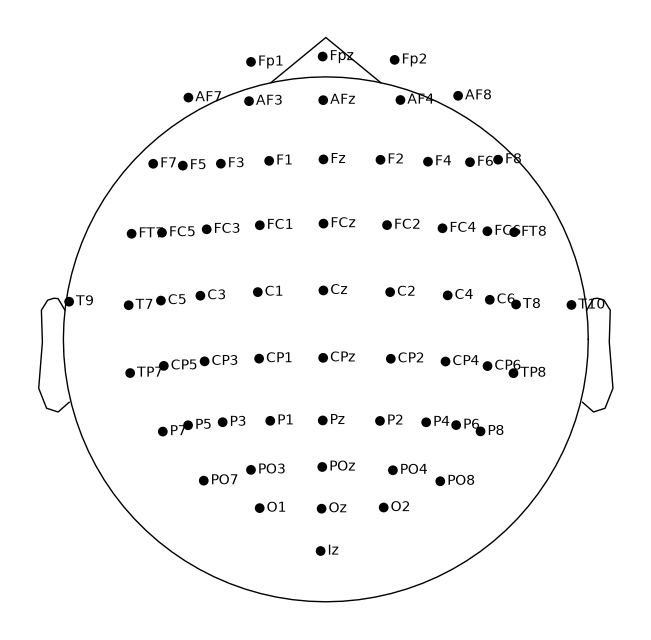

C3 [-0.06714873  0.02335823  0.10451068]
Cz [-0.00137414  0.02761709  0.14019949]
C4 [0.06532887 0.0235731  0.10369243]


In [15]:
raw_for_plot.plot_sensors(
    show_names=True,
    ch_type="eeg"
)

montage = raw_for_plot.get_montage()
positions = montage.get_positions()["ch_pos"]

for channel in ["C3", "Cz", "C4"]:
    print(channel, positions[channel])

I selected C3, Cz, and C4 because they are central scalp electrodes commonly used in motor-imagery EEG.

Because this EDF file does not contain individualized sensor digitization, I use a standard montage to inspect approximate scalp positions. These positions should not be interpreted as exact motor cortex source locations.

The sensor plot confirms that C3 is left-central, Cz is central midline, and C4 is right-central in the standard montage.

### EEG Raw data plot preview

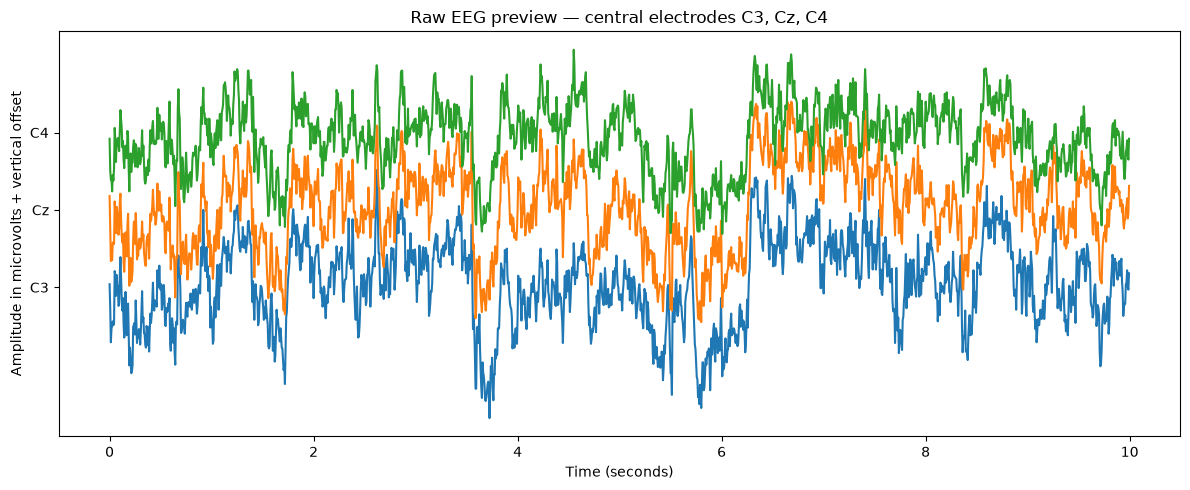

PosixPath('/Users/heihei/Desktop/neurosignallab/figures/week3_s001r04_raw_eeg_preview.png')

In [16]:
raw_for_plot = raw.copy()

eegbci.standardize(raw_for_plot)
raw_for_plot.set_montage("standard_1005")

plot_channels = ["C3", "Cz", "C4"]

start_time = 0
duration = 10

sfreq = raw_for_plot.info["sfreq"]
start_sample = int(start_time * sfreq)
stop_sample = int((start_time + duration) * sfreq)

raw_subset = raw_for_plot.copy().pick(plot_channels)

data, times = raw_subset.get_data(
    start=start_sample,
    stop=stop_sample,
    return_times=True
)

data_microvolts = data * 1e6 
#MNE loads data in Volts, but typically data is interpreted in microvolts

offset = 100
#Since the plot is for visualization, we can offset the channels

plt.figure(figsize=(12, 5))

for i, channel in enumerate(plot_channels):
    plt.plot(
        times,
        data_microvolts[i] + i * offset,
        label=channel
    )

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude in microvolts + vertical offset")
plt.title("Raw EEG preview — central electrodes C3, Cz, C4")
plt.yticks(
    [i * offset for i in range(len(plot_channels))],
    plot_channels
)
plt.tight_layout()

raw_preview_path = FIGURES_DIR / "week3_s001r04_raw_eeg_preview.png"
plt.savefig(raw_preview_path, dpi=150)

plt.show()

raw_preview_path

The raw EEG preview shows a short segment of continuous EEG from electrodes C3, Cz, and C4. These channels are commonly inspected in motor-imagery EEG because they are located over central scalp regions.

The raw traces look plausible for unfiltered EEG: they are not flat, they vary continuously over time, and the three channels show related activity. Keep in mind that this plot serves as a visual check

## Event timeline visualization

The event timeline shows when each annotation/event occurs during the recording. The x-axis shows time in seconds, and the y-axis shows the event label.

This plot verifies that the task labels are distributed across the recording and that the event timing looks sensible before creating epochs.

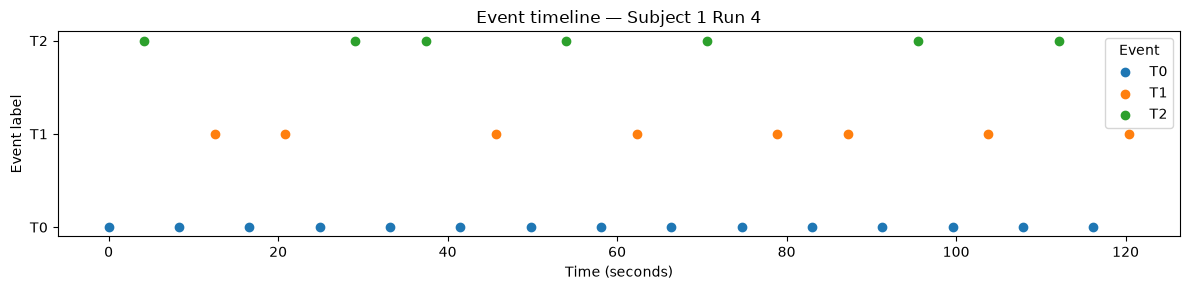

PosixPath('/Users/heihei/Desktop/neurosignallab/figures/week3_s001r04_event_timeline.png')

In [17]:
label_order = ["T0", "T1", "T2"]

label_to_y = {
    "T0": 0,
    "T1": 1,
    "T2": 2,
}

plt.figure(figsize=(12, 3))

for label in label_order:
    is_this_label = events_df["label"] == label
    label_events = events_df[is_this_label]

    x_values = label_events["time_seconds"]
    y_values = [label_to_y[label]] * len(label_events)

    plt.scatter(
        x_values,
        y_values,
        label=label
    )

plt.yticks(
    [0, 1, 2],
    ["T0", "T1", "T2"]
)

plt.xlabel("Time (seconds)")
plt.ylabel("Event label")
plt.title("Event timeline — Subject 1 Run 4")
plt.legend(title="Event")
plt.tight_layout()

event_timeline_path = FIGURES_DIR / "week3_s001r04_event_timeline.png"
plt.savefig(event_timeline_path, dpi=150)

plt.show()

event_timeline_path

The event timeline shows the timing of `T0`, `T1`, and `T2` events across the full recording. Each dot represents one event.

This plot confirms that the event labels are spread throughout the recording and that the event structure looks organized before epoching.

In this run, `T0` appears between many task events, which is consistent with rest periods separating motor-imagery events.